# 1. AOI Polygon Creation – Kurunegala District

This notebook creates the Area of Interest (AOI) polygon for the **Kurunegala District, Sri Lanka** using the GADM administrative boundary file.


In [3]:
import geopandas as gpd
import os

Loaded 323 administrative divisions from Sri Lanka
Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']

Found 30 divisions in Kurunegala District:
  - Alawwa
  - Ambanpola
  - Bamunakotuwa
  - Bingiriya
  - Ehetuwewa
  - Galgamuwa
  - Ganewatta
  - Giribawa
  - Ibbagamuwa
  - Katupotha
  - Kobeigane
  - Kotavehera
  - Kuliyapitiya East
  - Kuliyapitiya West
  - Kurunegala
  - Mahawa
  - Mallawapitiya
  - Maspotha
  - Mawathagama
  - Narammala
  - Nikaweratiya
  - Panduwasnuwara
  - Pannala
  - Polgahawela
  - Polpithigama
  - Rasnayakapura
  - Rideegama
  - Udubaddawa
  - Wariyapola
  - Weerambugedara

Saved Kurunegala AOI → ../AOI/Kurunegala_District_AOI.geojson
Area of Interest contains 30 administrative divisions

AOI CRS: EPSG:4326
AOI bounds: [79.90039063  7.25597382 80.57588196  8.19643402]


<Axes: >

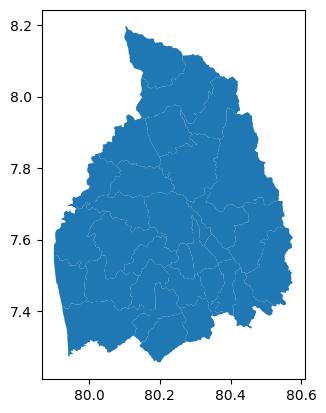

In [ ]:
# ==========================================
# AOI CREATION FOR KURUNEGALA DISTRICT
# Urbanization Monitoring Project 2015–2025
# ==========================================

import geopandas as gpd
import os

# Path to Sri Lanka GADM file
gadm_path = "../AOI/gadm41_LKA.gpkg"

# Output AOI file path
out_path = "../AOI/Kurunegala_District_AOI.geojson"


# ==============================
# 2. LOAD GADM FILE
# ==============================

gdf = gpd.read_file(gadm_path, layer="ADM_ADM_2")

print(f"Loaded {len(gdf)} administrative divisions from Sri Lanka")
print(f"Columns: {list(gdf.columns)}")


# ==============================
# 3. FILTER KURUNEGALA DISTRICT
# ==============================

mask = gdf["NAME_1"].str.lower().str.contains("kurunegala", na=False)
aoi = gdf[mask].to_crs("EPSG:4326")

print(f"\nFound {len(aoi)} divisions in Kurunegala District:")

for division in sorted(aoi["NAME_2"].tolist()):
    print(f"  - {division}")


# ==============================
# 4. SAVE AOI AS GEOJSON
# ==============================

os.makedirs(os.path.dirname(out_path), exist_ok=True)

aoi.to_file(out_path, driver="GeoJSON")

print(f"\nSaved Kurunegala AOI → {out_path}")
print(f"Area of Interest contains {len(aoi)} administrative divisions")


# ==============================
# 5. QUICK CHECK
# ==============================

print("\nAOI CRS:", aoi.crs)
print("AOI bounds:", aoi.total_bounds)

aoi.plot()